# Fine-tuning EfficientNet-B0 на високороздільному датасеті


## Що робить цей ноутбук

Бере **вже натреновану на CIFAKE модель** і донавчає її на високороздільному датасеті
(`Parveshiiii/AI-vs-Real` з HuggingFace), щоб виправити проблему out-of-distribution generalization
— коли модель видавала 100% synthetic для будь-якого реального фото з телефону.

## Зміни порівняно з оригінальним тренуванням

1. **Препроцесинг без сплющення**: `Resize(256)` по коротшій стороні + `CenterCrop(224)` — стандартна ImageNet-схема
2. **Стартовий чекпоінт** — твоя CIFAKE-модель `efficientnet_b0_synthdetect.pth` (а не ImageNet pretrained з нуля)
3. **Низький learning rate** (1e-5, в 10 разів менший за оригінал) — щоб не зруйнувати знання моделі
4. **Менше епох** (5 замість 10) — донавчання, не тренування з нуля
5. **Високороздільний датасет** з SD 3, SDXL, DALL-E, Midjourney проти реальних фото


## 1. Перевірка GPU

In [ ]:
import torch
import sys

print(f"Python:  {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")


Python:  3.12.13
PyTorch: 2.10.0+cu128
CUDA:    True
GPU:     Tesla T4


## 2. Встановлення залежностей

In [ ]:
!pip install -q datasets huggingface_hub scikit-learn matplotlib seaborn tqdm


## 3. Завантаження попередньої CIFAKE-моделі


In [ ]:
from google.colab import files
import os

print("Залий попередню модель: efficientnet_b0_synthdetect.pth")
uploaded = files.upload()

# Перейменуємо для зрозумілості
old_filename = list(uploaded.keys())[0]
os.rename(old_filename, '/content/efficientnet_b0_synthdetect_v1.pth')
print(f"Збережено: /content/efficientnet_b0_synthdetect_v1.pth ({os.path.getsize('/content/efficientnet_b0_synthdetect_v1.pth') / 1e6:.1f} MB)")


Залий попередню модель: efficientnet_b0_synthdetect.pth


Saving efficientnet_b0_synthdetect.pth to efficientnet_b0_synthdetect.pth
Збережено: /content/efficientnet_b0_synthdetect_v1.pth (16.3 MB)


## 4. Завантаження високороздільного датасету з HuggingFace

`Parveshiiii/AI-vs-Real` — балансовий датасет з:
- AI-зображення від Stable Diffusion, SDXL, DALL-E, Midjourney
- Реальні фото від людей (різна роздільна, різні сцени, не сплющені 32×32)
- Структура: `train/ai`, `train/real`, `test/ai`, `test/real`

Викачається ~1-2 ГБ.


In [ ]:
from datasets import load_dataset

# verification_mode='no_checks' — обходить помилку невідповідності метаданих
ds = load_dataset("Parveshiiii/AI-vs-Real", verification_mode='no_checks')
print("Splits знайдено:", list(ds.keys()))
print("Розміри:", {k: len(v) for k, v in ds.items()})

# Якщо нема 'test' split — розбиваємо train 80/20
if 'test' not in ds:
    print("\n'test' split не знайдено — розбиваємо train 80/20")
    ds = ds['train'].train_test_split(test_size=0.2, seed=42)
    print(f"Після розбиття: train={len(ds['train']):,}, test={len(ds['test']):,}")

print()
print("Поля у запису:", list(ds['train'][0].keys()))

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

Splits знайдено: ['train']
Розміри: {'train': 13999}

'test' split не знайдено — розбиваємо train 80/20
Після розбиття: train=11,199, test=2,800

Поля у запису: ['image', 'binary_label']


In [ ]:
# Подивитись структуру датасету
print("Колонки у записі:", list(ds['train'][0].keys()))
print("Features:", ds['train'].features)
print("\nПриклад запису:")
sample = ds['train'][0]
for k, v in sample.items():
    print(f"  {k}: {type(v).__name__} = {v if isinstance(v, (int, str)) else '...'}")

Колонки у записі: ['image', 'binary_label']
Features: {'image': Image(mode=None, decode=True), 'binary_label': Value('int64')}

Приклад запису:
  image: JpegImageFile = ...
  binary_label: int = 1


## 5. Імпорти та конфігурація

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

CONFIG = {
    'image_size': 224,
    'resize_short_edge': 256,         # для preprocess: коротша сторона спочатку → 256, потім center crop 224

    # Fine-tuning параметри
    'batch_size': 32,                 # менший ніж при первинному тренуванні (фото великі, пам'яті треба більше)
    'num_epochs': 5,                  # донавчання, тому менше епох
    'learning_rate': 1e-5,            # в 10 разів нижчий — щоб не зруйнувати CIFAKE-знання
    'weight_decay': 1e-5,
    'num_workers': 2,

    # Шляхи
    'starting_checkpoint': '/content/efficientnet_b0_synthdetect_v1.pth',
    'model_save_path': '/content/efficientnet_b0_synthdetect_v2.pth',
    'seed': 42,
}

# Repro
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Пристрій: {device}")


Пристрій: cuda


## 6. Трансформації — стандартна ImageNet-схема (без сплющення)

**ВАЖЛИВО:** ці transforms мають збігатися з тими що в ML-сервісі (`app/preprocess.py`).
Якщо preprocess в inference не співпаде з preprocess у тренуванні — модель погано працює.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train: з аугментаціями (random crop, flip, color jitter) — для робастності
train_transform = transforms.Compose([
    transforms.Resize(CONFIG['resize_short_edge']),         # коротша сторона → 256
    transforms.RandomResizedCrop(CONFIG['image_size'], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Eval: без аугментацій — просто resize + center crop
eval_transform = transforms.Compose([
    transforms.Resize(CONFIG['resize_short_edge']),
    transforms.CenterCrop(CONFIG['image_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## 7. Wrapper для HuggingFace dataset

HF dataset зберігає зображення як PIL у полі `image`, label у полі `label`.
Конвертуємо у звичний PyTorch Dataset з нашими transforms.

Мапінг класів: **0 = ai (synthetic), 1 = real** — так само як було у CIFAKE (FAKE=0, REAL=1).
Тому ваги моделі сумісні без перевпорядкування.


In [ ]:
class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.hf_dataset = hf_dataset
        self.transform = transform
        self.classes = ['ai', 'real']

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        label = item['binary_label']
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = HFImageDataset(ds['train'], train_transform)
val_ds   = HFImageDataset(ds['test'],  eval_transform)

print(f"Train: {len(train_ds):,} зображень")
print(f"Test:  {len(val_ds):,} зображень")

train_loader = DataLoader(
    train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=CONFIG['num_workers'], pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True
)


Train: 11,199 зображень
Test:  2,800 зображень


## 8. Модель: завантажуємо EfficientNet-B0 з нашого CIFAKE чекпоінта

In [ ]:
def build_model(num_classes: int = 2) -> nn.Module:
    """EfficientNet-B0 з адаптованою бінарною головою."""
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_model().to(device)

# Завантажуємо ваги з попереднього CIFAKE-тренування
checkpoint = torch.load(
    CONFIG['starting_checkpoint'], map_location=device, weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"✓ Завантажено CIFAKE-модель")
print(f"  Попередня val_acc: {checkpoint.get('val_acc', '?'):.4f}")
print(f"  Попередня епоха:   {checkpoint.get('epoch', '?')}")

total_params = sum(p.numel() for p in model.parameters())
print(f"  Параметрів:        {total_params:,}")


✓ Завантажено CIFAKE-модель
  Попередня val_acc: 0.9883
  Попередня епоха:   9
  Параметрів:        4,010,110


## 9. Loss, optimizer, scheduler — для fine-tuning

Учбове правило fine-tuning'у: **низький LR + менше епох**, щоб модель не "забула"
що навчила раніше і поступово адаптувалась до нового домену.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)
# CosineAnnealing — плавно зменшує LR до 0 за час навчання
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['num_epochs']
)


## 10. Функції тренування та валідації

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Повертає loss, передбачення, мітки, ймовірності класу AI (=synthetic)."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs_ai = [], [], []
    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs_ai.extend(probs[:, 0].cpu().numpy())  # P(AI)
    return (
        running_loss / len(loader.dataset),
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs_ai),
    )


## 11. Запуск fine-tuning

Зберігаємо найкращий чекпоінт за val_acc.


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0

# Спочатку — baseline на нашій тестовій вибірці БЕЗ fine-tune
# щоб побачити наскільки модель погано працює зараз на high-res
print("=== Baseline (CIFAKE-модель на high-res датасеті) ===")
val_loss, preds, labels, _ = evaluate(model, val_loader, criterion, device)
val_acc = accuracy_score(labels, preds)
print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
print()

best_acc = val_acc

for epoch in range(CONFIG['num_epochs']):
    print(f"\n=== Епоха {epoch+1}/{CONFIG['num_epochs']} ===")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_labels, _ = evaluate(model, val_loader, criterion, device)
    val_acc = accuracy_score(val_labels, val_preds)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"Val:   loss={val_loss:.4f}  acc={val_acc:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'classes': ['ai', 'real'],
            'class_to_idx': {'ai': 0, 'real': 1},
            'config': CONFIG,
            'epoch': epoch + 1,
            'val_acc': val_acc,
            'arch': 'efficientnet_b0',
            'finetuned_from': 'efficientnet_b0_synthdetect_v1.pth',
            'finetuned_on': 'Parveshiiii/AI-vs-Real',
        }, CONFIG['model_save_path'])
        print(f"✓ Збережено модель v2 (val_acc={val_acc:.4f})")

print(f"\n🎯 Найкраща val_acc після fine-tuning: {best_acc:.4f}")


=== Baseline (CIFAKE-модель на high-res датасеті) ===


Eval:   0%|          | 0/88 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0fe8278ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0fe8278ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Val loss: 10.4372 | Val acc: 0.3679


=== Епоха 1/5 ===


Train:   0%|          | 0/350 [00:00<?, ?it/s]

...

Train: loss=0.1737  acc=0.9472
Val:   loss=0.1809  acc=0.9500  lr=9.55e-07
✓ Збережено модель v2 (val_acc=0.9500)

=== Епоха 5/5 ===


Train:   0%|          | 0/350 [00:00<?, ?it/s]

Eval:   0%|          | 0/88 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0fe8278ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child processTraceback (most recent call last):

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0fe8278ae0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train: loss=0.1667  acc=0.9476
Val:   loss=0.1731  acc=0.9529  lr=0.00e+00
✓ Збережено модель v2 (val_acc=0.9529)

🎯 Найкраща val_acc після fine-tuning: 0.9529


## 12. Графіки навчання

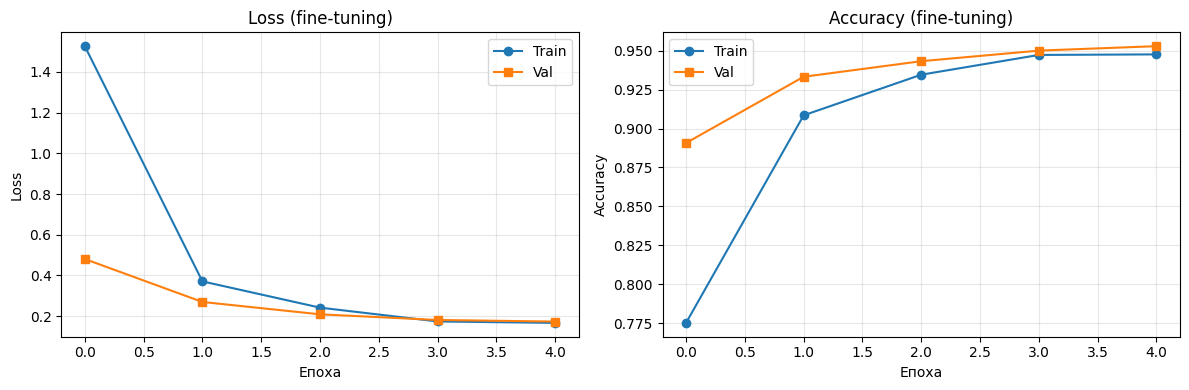

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='s')
ax1.set_title('Loss (fine-tuning)')
ax1.set_xlabel('Епоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', marker='o')
ax2.plot(history['val_acc'],   label='Val',   marker='s')
ax2.set_title('Accuracy (fine-tuning)')
ax2.set_xlabel('Епоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/finetune_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Фінальна оцінка з повним набором метрик

In [ ]:
# Завантажуємо найкращий чекпоінт
checkpoint_v2 = torch.load(CONFIG['model_save_path'], map_location=device, weights_only=False)
model.load_state_dict(checkpoint_v2['model_state_dict'])
print(f"Завантажено модель v2 з епохи {checkpoint_v2['epoch']}, val_acc={checkpoint_v2['val_acc']:.4f}")

_, preds, labels, probs_ai = evaluate(model, val_loader, criterion, device)

# Positive class = AI (synthetic)
y_true_ai  = (labels == 0).astype(int)
y_pred_ai  = (preds  == 0).astype(int)
y_score_ai = probs_ai

acc  = accuracy_score(labels, preds)
prec = precision_score(y_true_ai, y_pred_ai)
rec  = recall_score(y_true_ai, y_pred_ai)
f1   = f1_score(y_true_ai, y_pred_ai)
auc  = roc_auc_score(y_true_ai, y_score_ai)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТИ ПІСЛЯ FINE-TUNING")
print("=" * 50)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive=AI)")
print(f"Recall:    {rec:.4f}  (positive=AI)")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("=" * 50)

print("\nДетальний classification report:")
print(classification_report(labels, preds, target_names=['ai', 'real'], digits=4))


Завантажено модель v2 з епохи 5, val_acc=0.9529


Eval:   0%|          | 0/88 [00:00<?, ?it/s]


РЕЗУЛЬТАТИ ПІСЛЯ FINE-TUNING
Accuracy:  0.9529
Precision: 0.9045  (positive=AI)
Recall:    0.8964  (positive=AI)
F1-score:  0.9005
AUC-ROC:   0.9841

Детальний classification report:
              precision    recall  f1-score   support

          ai     0.9045    0.8964    0.9005       666
        real     0.9678    0.9705    0.9691      2134

    accuracy                         0.9529      2800
   macro avg     0.9362    0.9334    0.9348      2800
weighted avg     0.9527    0.9529    0.9528      2800



## 14. Confusion Matrix і ROC

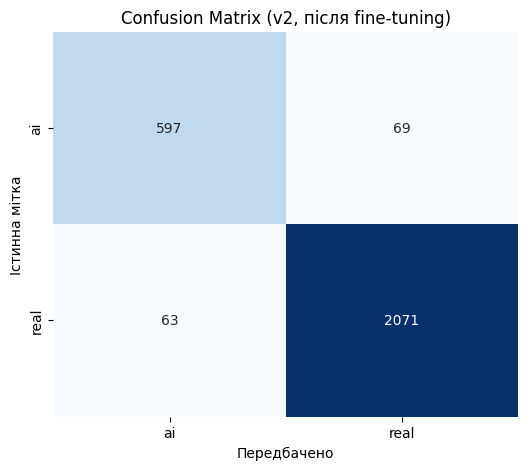

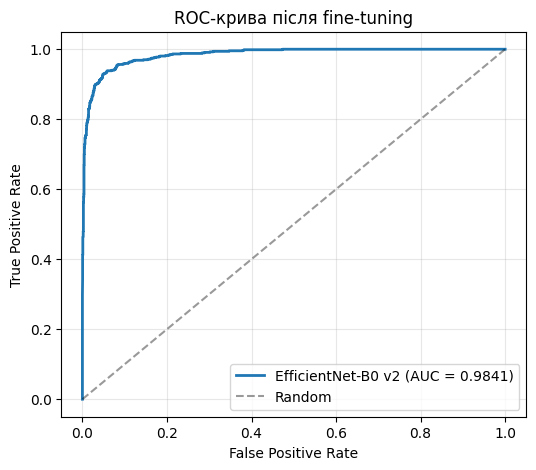

In [ ]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ai', 'real'], yticklabels=['ai', 'real'],
            ax=ax, cbar=False)
ax.set_xlabel('Передбачено'); ax.set_ylabel('Істинна мітка')
ax.set_title('Confusion Matrix (v2, після fine-tuning)')
plt.savefig('/content/finetune_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fpr, tpr, _ = roc_curve(y_true_ai, y_score_ai)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'EfficientNet-B0 v2 (AUC = {auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-крива після fine-tuning')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.savefig('/content/finetune_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Sanity check: інференс на прикладах

Подивимось як модель прогнозує на кількох випадкових зображеннях з тестової вибірки.


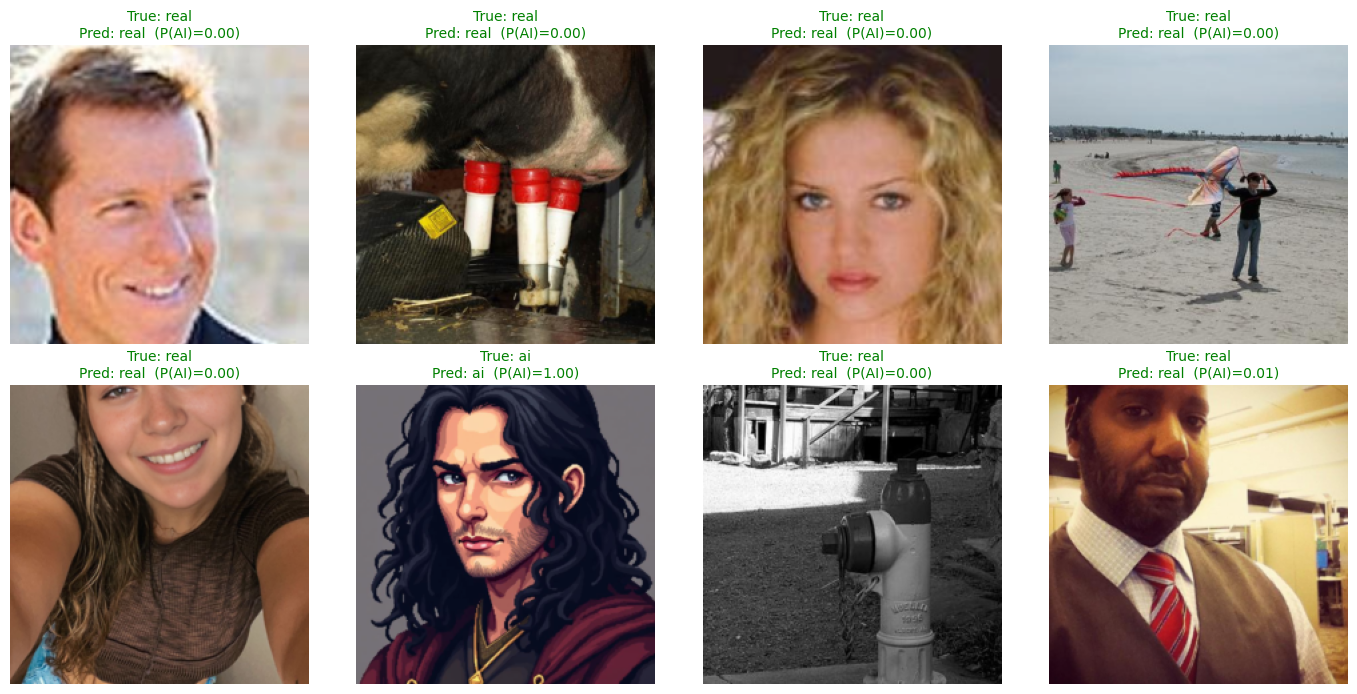

In [ ]:
import random as random_module

model.eval()
classes = ['ai', 'real']

# 8 випадкових прикладів з val
sample_indices = random_module.sample(range(len(val_ds)), 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, sample_indices):
    img_tensor, true_label = val_ds[idx]
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
        pred = out.argmax(dim=1).item()

    # Денормалізуємо для візуалізації
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img)
    ax.set_title(
        f"True: {classes[true_label]}\n"
        f"Pred: {classes[pred]}  (P(AI)={probs[0].item():.2f})",
        color=color, fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()


## 16. Завантаження артефактів

На вихід — нова модель `v2` + графіки для дипломної.


In [ ]:
from google.colab import files

print("Завантажуємо артефакти на твій компʼютер:")
files.download(CONFIG['model_save_path'])
files.download('/content/finetune_history.png')
files.download('/content/finetune_confusion_matrix.png')
files.download('/content/finetune_roc_curve.png')


Завантажуємо артефакти на твій компʼютер:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Що робити далі ===
1. Поклади efficientnet_b0_synthdetect_v2.pth у synthdetect/ml-service/models/
2. У ml-service/.env постав: MODEL_PATH=models/efficientnet_b0_synthdetect_v2.pth
3. (Опційно) MODEL_VERSION=efficientnet_b0_v2.0_finetuned
4. Перезапусти uvicorn — нова модель завантажиться
5. Тестуй з реальними фото — мають класифікуватись правильно
